# **Model 4 Parameters:**
## **Inputs:** SMILES strings of chemical structures and experimental DMSO-normalized ZBTB11 and IKZF1 abundance values at 10 test MGD concentrations (%)
## **Outputs:** Predicted ZBTB11 and IKZF1 abundance values at each MGD concentration (%)
## **Approach:** Multi-target Chemprop v2 with Optuna wrapper for hyperparameter tuning
## **Baseline:** Ridge Regression on Morgan fingerprints
### Data splitting by computed Bemis-Murcko scaffolds using astartes package
* 80/10/10% train/validation/test

**Package installs and file loading**

In [1]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model3"

In [2]:
!pip install optuna lightning chemprop ipywidgets umap-learn matplotlib seaborn 

In [3]:
!pip install torch --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [4]:
import pandas as pd
import torch
import optuna
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lightning import pytorch as pl
from chemprop import data, featurizers, models, nn
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from lightning.pytorch.loggers import CSVLogger

**Synthetic Data Generation**

Uncomment code chunk below if you want to test code adjustments with randomly generated dataset

In [5]:
# print("Generating synthetic molecular glue dataset...")

# # 1. Generate 100 valid SMILES strings
# # We use a basic amide-phenyl scaffold and grow an aliphatic chain to create unique molecules
# smiles_list = [f"O=C(Nc1ccccc1)C{'C'*i}" for i in range(1, 41)] + \
#               [f"O=C(Nc1ccc(Cl)cc1)C{'C'*i}" for i in range(1, 31)] + \
#               [f"O=C(Nc1ccc(F)cc1)C{'C'*i}" for i in range(1, 31)]

# df = pd.DataFrame({'SMILES': smiles_list})

# # 2. Assign distinct splits (70 Train / 15 Val / 15 Test)
# df['Dataset'] = ['Train'] * 70 + ['Val'] * 15 + ['Test'] * 15

# # 3. Generate dummy ZBTB11 data
# # pDC50 between 5.0 (10 uM) and 9.0 (1 nM), Dmax between 20% and 100%
# np.random.seed(42) # For reproducible random numbers
# df['ZBTB11_pDC50'] = np.random.uniform(5.0, 9.0, 100)
# df['ZBTB11_Dmax'] = np.random.uniform(20.0, 100.0, 100)

# # 4. Generate dummy IKZF1 data
# df['IKZF1_pDC50'] = np.random.uniform(4.0, 8.0, 100)
# df['IKZF1_Dmax'] = np.random.uniform(0.0, 100.0, 100)

# # 5. Inject 'NaN' values to simulate Inactive Compounds
# # Let's pick 10 random molecules and make them completely inactive against IKZF1
# inactive_indices = np.random.choice(100, 10, replace=False)
# df.loc[inactive_indices, 'IKZF1_Dmax'] = 0.0
# df.loc[inactive_indices, 'IKZF1_pDC50'] = np.nan # This tests Chemprop's masking feature!

# # 6. Save to CSV
# csv_filename = "zbtb11_mgd_input.csv"
# df.to_csv(csv_filename, index=False)

# print(f"Successfully saved 100 test molecules to '{csv_filename}'.")
# print("\nSample of the generated data:")
# print(df.head())

**Data Splitting and Loading**

In [6]:
def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)))
        else:
            fps.append(np.zeros((n_bits,)))
    return np.array(fps)


# 1. LOAD FULL DATASET & DEFINE 20 TARGETS
df = pd.read_csv("zbtb11_mgd_input.csv")

concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
targets = [f'zbtb11_{c}' for c in concs] + [f'ikzf1_{c}' for c in concs]

def clean_assay_data(df, target_cols):
    df[target_cols] = df[target_cols].apply(pd.to_numeric, errors='coerce')
    df[target_cols] = df[target_cols].clip(lower=0, upper=100)              
    return df.dropna(subset=target_cols, how='all')                         

df = clean_assay_data(df, targets)

smiles_list = df['SMILES'].tolist()
y_values = df[targets].values


# 2. CREATE CHEM PROP DATAPOINTS & GENERATE SCAFFOLD SPLIT
all_datapoints = [
    data.MoleculeDatapoint.from_smi(smi, y) 
    for smi, y in zip(smiles_list, y_values)
]

all_mols = [d.mol for d in all_datapoints]
train_idx, val_idx, test_idx = data.make_split_indices(
    all_mols,
    split="scaffold_balanced", 
    sizes=(0.8, 0.1, 0.1), 
    seed=42
)


# 3. APPLY INDICES TO CHEM PROP (DEEP LEARNING PREP)
print(f"Applying splits to Chemprop... (Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)})")
train_data, val_data, test_data = data.split_data_by_indices(
    all_datapoints, train_idx, val_idx, test_idx
)

featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
train_dset = data.MoleculeDataset(train_data[0], featurizer)
val_dset = data.MoleculeDataset(val_data[0], featurizer)
test_dset = data.MoleculeDataset(test_data[0], featurizer)

output_scaler = train_dset.normalize_targets()
val_dset.normalize_targets(output_scaler)
test_dset.normalize_targets(output_scaler)

train_loader = data.build_dataloader(train_dset, shuffle=True, num_workers=0)
val_loader = data.build_dataloader(val_dset, shuffle=False, num_workers=0)
test_loader = data.build_dataloader(test_dset, shuffle=False, num_workers=0)


# 4. APPLY INDICES TO PANDAS/SCIKIT-LEARN (CLASSICAL ML PREP)
train_idx_flat = np.array(train_idx).flatten()
test_idx_flat = np.array(test_idx).flatten()

train_df = df.iloc[train_idx_flat].copy()
test_df = df.iloc[test_idx_flat].copy()

X_train = smiles_to_morgan(train_df['SMILES'].tolist())
X_test = smiles_to_morgan(test_df['SMILES'].tolist())

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("Unified data preparation complete!")

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


Applying splits to Chemprop... (Train: 1, Val: 1, Test: 1)
Unified data preparation complete!


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\astartes\main.py:325: ImperfectSplittingWarning: Actual train/test split differs from requested size. Requested train size of 0.80, got 0.82. Requested validation size of 0.10, got 0.09. Requested test size of 0.10, got 0.09. 
  warn(
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use MorganGenerator
[22:59:53] DEPRECATION WARNING: please use 

**Baseline Ridge Regression Model Training and Evaluation**


--- Top Predicted Selective Compounds ---
                                               SMILES  \
73  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...   
69  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...   
77  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...   
46  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC(S(=O)(...   
45  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...   

    Pred_ZBTB11_Selectivity  True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  \
73               -33.934756              -222.320777       433.625188   
69               -58.226386              -288.607287       428.705444   
77              -109.273555              -141.692576       415.451101   
46              -110.097523                 1.011474       411.931851   
45              -117.039719                 2.552514       391.920451   

    True_ZBTB11_AUC  
73       450.723594  
69       436.649134  
77       438.465436  
46       420.347358  
45       404.461537  


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


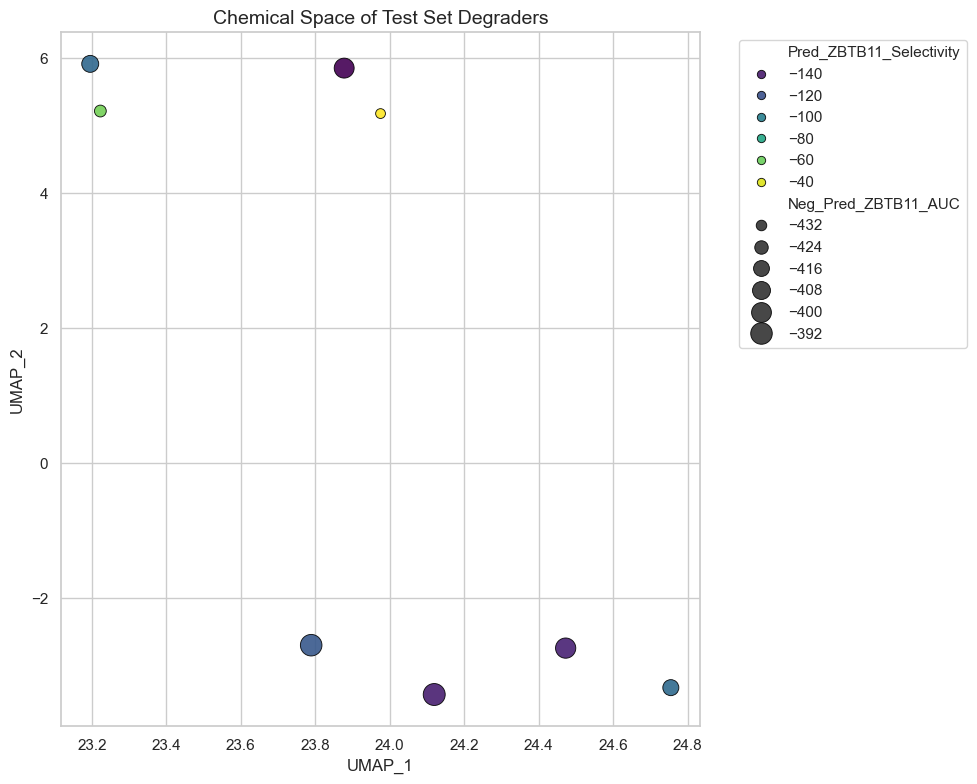


Overall Average Across All Concentrations -> RMSE: 17.942 | R²: -5.830

--- Baseline Regression Metrics (Per Concentration) ---
    Endpoint  N_Valid   RMSE    MAE      R²  Pearson_r
  zbtb11_3nM        8  1.195  1.033   0.137      0.581
 zbtb11_10nM        8  1.970  1.838  -0.815     -0.041
 zbtb11_30nM        8  3.450  3.325 -17.556      0.493
zbtb11_100nM        8  5.238  5.002  -4.078      0.756
zbtb11_300nM        8  7.750  7.639 -31.086      0.722
  zbtb11_1uM        8 10.391  9.919 -47.069     -0.291
  zbtb11_3uM        8  8.890  8.518  -6.557      0.655
 zbtb11_10uM        8  5.860  5.141  -0.744      0.715
 zbtb11_30uM        8  8.838  7.613   0.637      0.855
zbtb11_100uM        8 21.262 17.588   0.402      0.871
   ikzf1_3nM        8  6.711  4.373  -0.162     -0.279
  ikzf1_10nM        8 14.243 11.192  -0.144     -0.345
  ikzf1_30nM        8 27.878 23.366  -0.639     -0.627
 ikzf1_100nM        8 32.992 28.390  -0.800     -0.585
 ikzf1_300nM        8 35.422 31.453  -0.982   

In [14]:
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)


# 1. TRAIN 20 INDEPENDENT RIDGE MODELS
trained_models = {}
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]

for target in targets:
    y_train = train_df[target].values
    valid_mask = ~np.isnan(y_train)
    
    if valid_mask.sum() > 5:
        model = RidgeCV(alphas=alphas, cv=5)
        model.fit(X_train_scaled[valid_mask], y_train[valid_mask])
        trained_models[target] = model
    else:
        print(f"Warning: Not enough data for {target}. Skipping.")


# 2. PREDICT AND CALCULATE TRUE AREA UNDER CURVE (AUC)

true_target_cols = list(trained_models.keys())
test_results_df = test_df[['SMILES'] + true_target_cols].copy()

for target in trained_models.keys():
    test_results_df[f'Pred_{target}'] = trained_models[target].predict(X_test_scaled)

pred_zbtb11_cols = [f'Pred_zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
pred_ikzf1_cols = [f'Pred_ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

zbtb11_x = [log_conc[i] for i, c in enumerate(concs) if f'zbtb11_{c}' in trained_models]
ikzf1_x = [log_conc[i] for i, c in enumerate(concs) if f'ikzf1_{c}' in trained_models]

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_ridge_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds ---")
print(test_results_df[['SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 3. UMAP PLOTTING
test_results_df = test_results_df.sort_index()

reducer = umap.UMAP(n_neighbors=min(5, len(X_test) - 1), min_dist=0.1, metric='jaccard', random_state=42)
embeddings_2d = reducer.fit_transform(X_test)

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of Test Set Degraders", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("ridge_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# 4. EVALUATE REGRESSION METRICS
evaluation_results = []
valid_targets = list(trained_models.keys())

for true_col in valid_targets:
    pred_col = f'Pred_{true_col}'
    
    y_true = test_df.loc[test_results_df.index, true_col].values
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid': len(y_true_valid),
        'RMSE': round(rmse, 3), 
        'MAE': round(mae, 3),
        'R²': round(r2, 3), 
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_ridge_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Baseline Regression Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

**Chemprop Model Training and Evaluation**

[I 2026-03-10 23:26:49,332] A new study created in memory with name: no-name-5fa67214-3bf0-4b17-9428-812a89230f80
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_p

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 35.9 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 32.3 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 68.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 68.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=50` reached.
[I 2026-03-10 23:26:52,798] Trial 0 finished with value: 1.1712989807128906 and parameters: {'depth': 5, 'd_h': 100, 'dropout': 0.30000000000000004, 'n_layers': 3}. Best is trial 0 with value: 1.1712989807128906.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepp

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 35.9 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 32.3 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

...

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │  186 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 414 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 414 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=100` reached.


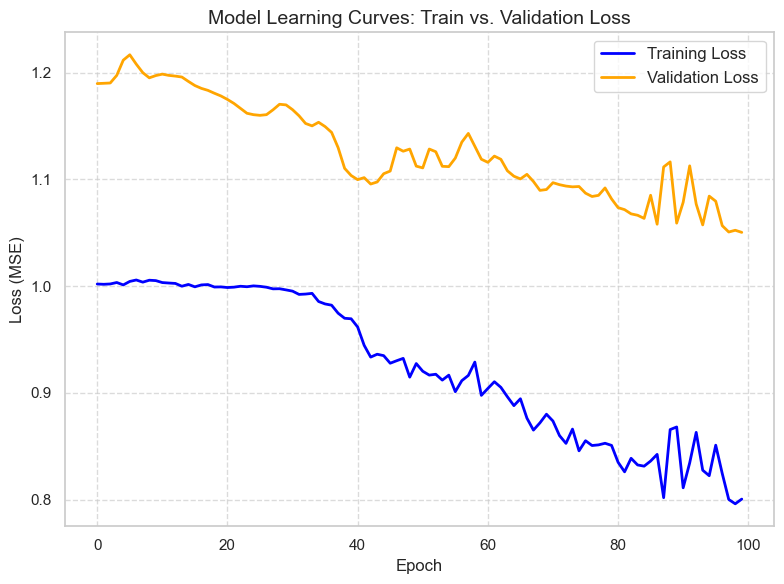

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---
                                              SMILES  Pred_ZBTB11_Selectivity  \
7  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...               -55.143279   
6  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...               -65.958690   
0  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...               -83.998591   
1  O=C1C2=CC=C(NC3=C(NC4(CCC4)C5=CC=C(OC)C=C5)C(C...               -97.993940   
3  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...              -101.811862   

   True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  True_ZBTB11_AUC  
7              -222.320777       445.213369       450.723594  
6              -288.607287       433.343248       436.649134  
0              -141.692576       413.931567       438.465436  
1              -105.402948       396.463355       430.996305  
3                 2.552514       386.636207       404.461537  
Extracted fingerprints shape: (8, 300)


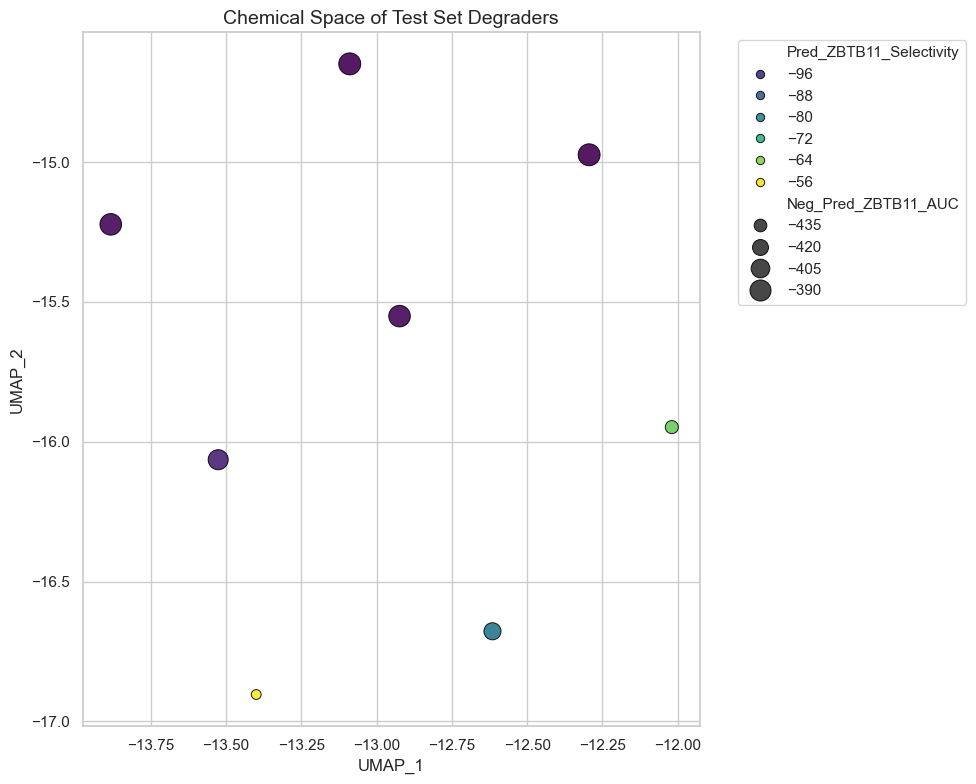


Overall Average Across All Concentrations -> RMSE: 17.500 | R²: -6.193

--- Regression Evaluation Metrics (Per Concentration) ---
    Endpoint  N_Valid_Points   RMSE    MAE      R²  Pearson_r
  zbtb11_3nM               8  1.228  1.047   0.089      0.434
 zbtb11_10nM               8  1.718  1.607  -0.380      0.338
 zbtb11_30nM               8  3.201  2.928 -14.967      0.435
zbtb11_100nM               8  5.030  4.237  -3.684      0.362
zbtb11_300nM               8  8.000  7.228 -33.189      0.411
  zbtb11_1uM               8 10.976  9.584 -52.638     -0.384
  zbtb11_3uM               8  8.928  7.919  -6.622      0.540
 zbtb11_10uM               8 11.188  9.350  -5.356      0.498
 zbtb11_30uM               8  8.604  7.194   0.656      0.826
zbtb11_100uM               8 18.566 16.303   0.544      0.875
   ikzf1_3nM               8  6.548  4.083  -0.106     -0.436
  ikzf1_10nM               8 14.869 11.201  -0.247     -0.843
  ikzf1_30nM               8 27.035 22.708  -0.542     -0.828
 

In [15]:
# 1. HYPERPARAMETER TUNING WITH OPTUNA
output_transform = nn.UnscaleTransform.from_standard_scaler(output_scaler)

def objective(trial):
    depth = trial.suggest_int("depth", 4, 6)
    d_h = trial.suggest_int("d_h", 100, 300, step=100)
    dropout = trial.suggest_float("dropout", 0.2, 0.5, step=0.1)
    n_layers = trial.suggest_int("n_layers", 2, 3)

    mp = nn.BondMessagePassing(depth=depth, d_h=d_h)
    agg = nn.MeanAggregation()

    ffn = nn.RegressionFFN(
        n_tasks=20,
        input_dim=mp.output_dim,
        hidden_dim=d_h,
        n_layers=n_layers,
        dropout=dropout,
        output_transform=output_transform
    )
    chemprop_model = models.MPNN(mp, agg, ffn)

    trainer = pl.Trainer(
        accelerator="auto",
        max_epochs=50,
        enable_checkpointing=False,
        enable_progress_bar=False,
        logger=False
    )
    trainer.fit(chemprop_model, train_loader, val_loader)

    return trainer.callback_metrics["val_loss"].item()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
print(f"Best hyperparameters found: {study.best_params}")


# 2. TRAIN FINAL MODEL & PLOT LOSS CURVEs
best = study.best_params

final_mp = nn.BondMessagePassing(depth=best["depth"], d_h=best["d_h"])
final_agg = nn.MeanAggregation()

final_ffn = nn.RegressionFFN(
    n_tasks=20,
    input_dim=final_mp.output_dim,
    hidden_dim=best["d_h"],
    n_layers=best["n_layers"],
    dropout=best["dropout"],
    output_transform=output_transform
)
final_model = models.MPNN(final_mp, final_agg, final_ffn)

logger = CSVLogger("training_logs", name="chemprop_model")

final_trainer = pl.Trainer(
    accelerator="auto",
    max_epochs=100,
    logger=logger, # <--- Attach the logger here
    enable_progress_bar=True,
    enable_checkpointing=True
)

final_trainer.fit(final_model, train_loader, val_loader)

metrics_file = f"{logger.log_dir}/metrics.csv"
metrics_df = pd.read_csv(metrics_file)

train_cols = [c for c in metrics_df.columns if 'train' in c.lower() and 'loss' in c.lower()]
val_cols = [c for c in metrics_df.columns if 'val' in c.lower() and 'loss' in c.lower()]
train_col = train_cols[0] if train_cols else ('loss' if 'loss' in metrics_df.columns else None)
val_col = val_cols[0] if val_cols else None

if train_col and val_col:
    train_loss = metrics_df[['epoch', train_col]].dropna().groupby('epoch').mean()
    val_loss = metrics_df[['epoch', val_col]].dropna().groupby('epoch').mean()

    plt.figure(figsize=(8, 6))
    plt.plot(train_loss.index, train_loss[train_col], label='Training Loss', color='blue', linewidth=2)
    plt.plot(val_loss.index, val_loss[val_col], label='Validation Loss', color='orange', linewidth=2)

    plt.title("Model Learning Curves: Train vs. Validation Loss", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss (MSE)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300)
    plt.show()
else:
    print("\nError: Could not find both train and validation loss columns in the logs.")


# 3. DEFINE TARGETS AND X-AXIS FOR INTEGRATION
concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs]
targets = true_zbtb11_cols + true_ikzf1_cols
pred_cols = [f'Pred_{t}' for t in targets]


# 4. PREDICT & CALCULATE TRUE AUC SELECTIVITY
preds = final_trainer.predict(final_model, test_loader)
preds_tensor = torch.concat(preds, axis=0)

test_smiles = [dp.name for dp in test_data[0]] 
true_targets = [dp.y for dp in test_data[0]] 

true_cols = true_zbtb11_cols + true_ikzf1_cols
test_results_df = pd.DataFrame(true_targets, columns=true_cols)
test_results_df.insert(0, 'SMILES', test_smiles)

pred_zbtb11_cols = [f'Pred_{t}' for t in true_zbtb11_cols]
pred_ikzf1_cols = [f'Pred_{t}' for t in true_ikzf1_cols]
test_results_df[pred_zbtb11_cols + pred_ikzf1_cols] = preds_tensor.numpy()

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_chemprop_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---")
print(test_results_df[['SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 5. EXTRACT LEARNED FINGERPRINTS FROM THE MODEL
final_model.cpu()
final_model.eval()

learned_fingerprints = []

with torch.no_grad():
    for batch in test_loader:
        molecule_embeddings = final_model.fingerprint(batch.bmg, batch.V_d, batch.X_d)
        learned_fingerprints.append(molecule_embeddings.numpy())

embeddings_array = np.vstack(learned_fingerprints)
print(f"Extracted fingerprints shape: {embeddings_array.shape}")


# 6. UMAP DIMENSIONALITY REDUCTION & PLOTTING
reducer = umap.UMAP(n_neighbors=min(15, len(embeddings_array) - 1), min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_array)

test_results_df = test_results_df.sort_index()

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of Test Set Degraders", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("chemprop_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# 7. EVALUATE REGRESSION METRICS FOR ALL 20 DOSES
y_true_array = np.array([dp.y for dp in test_data[0]])
evaluation_results = []

for idx, (true_col, pred_col) in enumerate(zip(targets, pred_cols)):
    y_true = y_true_array[:, idx]
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid_Points': len(y_true_valid),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_chemprop_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Regression Evaluation Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

# Conclusions
## Observations: 
* Switching from summary statistics (e.g. pDC50 and Dmax) to the normalized abundances at each tested MGD concentration improves the accuracy of the Ridge regression and Chemprop model predictions on ZBTB11 and IKZF1 degradation. However, all regression metrics indicate that both models' predictions of ZBTB11 degradation is significantly more accurate than their predictions of IKZF1 degradation at every tested concentration. It also seems that both models struggle to make accurate predictions on the protein abundances at higher concentrations (>=10 uM).
* The Ridge regression baseline model and the Chemprop MPNN model share comparable RMSE, MAE, and R^2 metrics to the test set's experimental ZBTB11 abundance values. However, Chemprop significantly outperforms Ridge regression in predicting IKZF1 abundance, showing a lower RMSE, MAE, and higher R^2. Pearson's r values seemed to fluctuate a lot, and both models shared similar amounts of negative outliers and highly positive values, but at different concentrations from each other. This may indicate that the models weighted protein abundances at certain concentrations differently from each other. Distinctly, the Ridge regression model predicted a wide range of different degradation values for the test set, whereas the Chemprop model predicted all test set molecules to share comparable degradation profiles.
* Interestingly, increasing  the allowable range of the hyperparameters, particularly the number of hidden dimensions ('d_h') to represent the molecular information, slightly improved predictive accuracy on ZBTB11 degradation but significantly decreased the accuracy on IKZF1 degradation. I initially thought that the increased hidden dimensions was allowing the model to memorize the core chemical scaffold and pushing it to overfit to the training data, so I increased the dropout significantly (to 0.5) to combat this overfitting. However, this approach only performed as well as my initial testing with the following hyperparameters: 'depth=5', 'd_h=300', 'dropout=0.2', 'n_layers=2'.

## Future Directions:
* I want to incorporate AlphaFold3 modeling and interface scores into this pipeline and observe whether or not this will improve the predictive accuracy of both (or one) models.
* I may need to tinker around with adjusting the weights of the loss function to highly penalize error on protein abundances at higher concentrations (>=10 uM), since these are the concentrations where we should observe most potent degradation if a molecule is an active degrader.
* Since the Pearson's r statistic has shown negative values for many test points, I have been thinking a lot about adding a contrastive loss term to the overall loss function, so that molecules can be more strictly clustered or tethered together by their activity against ZBTB11, IKZF1, or both.